# SisFall Dataset — Format Explorer

This notebook walks through the raw structure of the **SisFall** dataset: how files are organised, what the columns mean, and where the accelerometer and gyroscope signals live.

**Reference:** Sucerquia et al. (2017). *SisFall: A Fall and Movement Dataset.*  
SISTEMIC, Universidad de Antioquia – UDEA.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

SISFALL_PATH = 'SisFall_dataset'
print('Dataset root:', os.path.abspath(SISFALL_PATH))

Dataset root: /home/ubuntu/git/FD-CNN/SisFall_dataset


---
## 1. Directory structure

Each **subject** has its own sub-folder.  
Subject IDs follow the pattern:

| Prefix | Group | Age range |
|--------|-------|-----------|
| `SA`   | Young adults | 19–30 years |
| `SE`   | Elderly       | 60–75 years |

There are **23 young adults** (`SA01`–`SA23`) and **15 elderly participants** (`SE01`–`SE15`).

In [2]:
subjects = sorted(
    d for d in os.listdir(SISFALL_PATH)
    if os.path.isdir(os.path.join(SISFALL_PATH, d))
)

young   = [s for s in subjects if s.startswith('SA')]
elderly = [s for s in subjects if s.startswith('SE')]

print(f'Total subjects : {len(subjects)}')
print(f'Young adults   : {len(young)}  → {young[0]} … {young[-1]}')
print(f'Elderly        : {len(elderly)} → {elderly[0]} … {elderly[-1]}')

Total subjects : 38
Young adults   : 23  → SA01 … SA23
Elderly        : 15 → SE01 … SE15


In [3]:
# Count files per subject and show the first subject's file list
sa01_files = sorted(os.listdir(os.path.join(SISFALL_PATH, 'SA01')))

fall_files = [f for f in sa01_files if f.startswith('F')]
adl_files  = [f for f in sa01_files if f.startswith('D')]

print(f'SA01 — total files : {len(sa01_files)}')
print(f'  Fall trials (F*) : {len(fall_files)}')
print(f'  ADL  trials (D*) : {len(adl_files)}')
print()
print('First 10 files:')
for f in sa01_files[:10]:
    print(' ', f)

SA01 — total files : 155
  Fall trials (F*) : 75
  ADL  trials (D*) : 79

First 10 files:
  D01_SA01_R01.txt
  D02_SA01_R01.txt
  D03_SA01_R01.txt
  D04_SA01_R01.txt
  D05_SA01_R01.txt
  D05_SA01_R02.txt
  D05_SA01_R03.txt
  D05_SA01_R04.txt
  D05_SA01_R05.txt
  D06_SA01_R01.txt


---
## 2. File-name convention

```
<ACTIVITY_CODE>_<SUBJECT_ID>_<TRIAL>.txt
```

| Part | Example | Meaning |
|------|---------|----------|
| Activity code | `F05` | **Fall** type 05 — *forward fall while jogging* |
| Activity code | `D01` | **ADL** type 01 — *walking slowly* |
| Subject ID    | `SA01`| Young adult #01 |
| Trial         | `R04` | 4th repetition of this activity |

**Fall codes** run `F01`–`F15` (15 fall types).  
**ADL codes** run `D01`–`D19` (19 daily-living activity types).

In [4]:
# Parse filename components for the first few files
examples = [
    'F05_SA01_R04.txt',
    'D17_SE04_R02.txt',
    'D01_SA01_R01.txt',
    'F01_SA01_R01.txt',
]

fall_desc = {
    'F01': 'Fall forward (slip)', 'F05': 'Fall forward jogging (trip)',
    'F14': 'Fall backward while sitting',
}
adl_desc = {
    'D01': 'Walking slowly', 'D17': 'Getting in/out of car',
}

all_desc = {**fall_desc, **adl_desc}

print(f'{'Filename':<28} {'Code':<6} {'Subject':<8} {'Trial':<6} {'Description'}')
print('-' * 75)
for fname in examples:
    code, subj, trial = fname.replace('.txt','').split('_')
    desc = all_desc.get(code, '—')
    print(f'{fname:<28} {code:<6} {subj:<8} {trial:<6} {desc}')

Filename                     Code   Subject  Trial  Description
---------------------------------------------------------------------------
F05_SA01_R04.txt             F05    SA01     R04    Fall forward jogging (trip)
D17_SE04_R02.txt             D17    SE04     R02    Getting in/out of car
D01_SA01_R01.txt             D01    SA01     R01    Walking slowly
F01_SA01_R01.txt             F01    SA01     R01    Fall forward (slip)


---
## 3. Activity types — file and sample counts

For every activity code (F01–F15 falls, D01–D19 ADLs), the table below shows:

- **Files** — total number of `.txt` recordings across all subjects
- **Total samples** — sum of all rows in those files (at 200 Hz)
- **Avg duration (s)** — mean recording length per file

Rows highlighted in **dark red** are fall types; **dark blue** are ADL types; **dark purple** is the total row.

In [5]:
from collections import defaultdict

ACTIVITY_DESC = {
    # Falls (F01–F15)
    'F01': 'Fall forward — slip',
    'F02': 'Fall backward — slip',
    'F03': 'Fall lateral — slip',
    'F04': 'Fall forward — trip',
    'F05': 'Fall forward jogging — trip',
    'F06': 'Vertical fall — faint',
    'F07': 'Fall forward + table brace — faint',
    'F08': 'Fall forward while getting up',
    'F09': 'Fall lateral while getting up',
    'F10': 'Fall forward while sitting down',
    'F11': 'Fall backward while sitting down',
    'F12': 'Fall lateral while sitting down',
    'F13': 'Fall forward while seated — faint',
    'F14': 'Fall backward while seated — faint',
    'F15': 'Fall lateral while seated — faint',
    # ADLs (D01–D19)
    'D01': 'Walking slowly',
    'D02': 'Walking quickly',
    'D03': 'Jogging slowly',
    'D04': 'Jogging quickly',
    'D05': 'Walking upstairs and downstairs slowly',
    'D06': 'Walking upstairs and downstairs quickly',
    'D07': 'Sit in half-height chair slowly, then stand',
    'D08': 'Sit in half-height chair quickly, then stand',
    'D09': 'Sit in low chair slowly, then stand',
    'D10': 'Sit in low chair quickly, then stand',
    'D11': 'Try to get up, collapse into chair',
    'D12': 'Lie slowly from sitting, then sit again',
    'D13': 'Lie quickly from sitting, then sit again',
    'D14': 'Back to lateral position and back',
    'D15': 'Standing, bend at knees slowly, then up',
    'D16': 'Standing, bend without bending knees, then up',
    'D17': 'Get into a car, sit, then get out',
    'D18': 'Stumble while walking',
    'D19': 'Jump to reach a high object',
}

file_counts   = defaultdict(int)
sample_counts = defaultdict(int)

for subj in sorted(os.listdir(SISFALL_PATH)):
    subj_path = os.path.join(SISFALL_PATH, subj)
    if not os.path.isdir(subj_path):
        continue
    for fname in sorted(os.listdir(subj_path)):
        if not fname.endswith('.txt'):
            continue
        code = fname.split('_')[0]
        if code not in ACTIVITY_DESC:
            continue
        file_counts[code] += 1
        with open(os.path.join(subj_path, fname)) as fh:
            n = sum(1 for line in fh if ',' in line)
        sample_counts[code] += n

rows = []
for code in sorted(ACTIVITY_DESC):
    if code not in file_counts:
        continue
    n_files   = file_counts[code]
    n_samples = sample_counts[code]
    rows.append({
        'Code':             code,
        'Type':             'Fall' if code.startswith('F') else 'ADL',
        'Description':      ACTIVITY_DESC[code],
        'Files':            n_files,
        'Total samples':    n_samples,
        'Avg duration (s)': round(n_samples / n_files / 200, 1),
    })

summary_df = pd.DataFrame(rows)

# Totals row
totals = pd.DataFrame([{
    'Code': '—',
    'Type': '—',
    'Description': 'TOTAL',
    'Files': summary_df['Files'].sum(),
    'Total samples': summary_df['Total samples'].sum(),
    'Avg duration (s)': round(
        summary_df['Total samples'].sum() / summary_df['Files'].sum() / 200, 1
    ),
}])
display_df = pd.concat([summary_df, totals], ignore_index=True)

# Dark backgrounds with white text for readability on any theme
_FALL_STYLE  = 'background-color: #922b21; color: white'   # dark red
_ADL_STYLE   = 'background-color: #1a5276; color: white'   # dark blue
_TOTAL_STYLE = 'background-color: #4a235a; color: white'   # dark purple

def _row_style(row):
    if row['Description'] == 'TOTAL':
        return [_TOTAL_STYLE] * len(row)
    if row['Type'] == 'Fall':
        return [_FALL_STYLE] * len(row)
    return [_ADL_STYLE] * len(row)

styled = (
    display_df.style
    .apply(_row_style, axis=1)
    .format({'Total samples': '{:,}', 'Files': '{:,}'})
    .set_properties(**{'text-align': 'left', 'font-size': '13px'})
    .set_caption('SisFall activity types — file and sample counts (200 Hz)')
)
display(styled)

fall_total = summary_df[summary_df['Type'] == 'Fall']['Files'].sum()
adl_total  = summary_df[summary_df['Type'] == 'ADL']['Files'].sum()
print(f'\nFall recordings : {fall_total:,}  ({len(summary_df[summary_df["Type"]=="Fall"])} types)')
print(f'ADL  recordings : {adl_total:,}  ({len(summary_df[summary_df["Type"]=="ADL"])} types)')
print(f'Total           : {fall_total + adl_total:,}')

,Code,Type,Description,Files,Total samples,Avg duration (s)
0,D01,ADL,Walking slowly,38,"775,945",102.100000
1,D02,ADL,Walking quickly,38,"775,996",102.100000
2,D03,ADL,Jogging slowly,38,"775,983",102.100000
3,D04,ADL,Jogging quickly,36,"737,988",102.500000
4,D05,ADL,Walking upstairs and downstairs slowly,190,"949,954",25.000000
5,D06,ADL,Walking upstairs and downstairs quickly,118,"589,984",25.000000
6,D07,ADL,"Sit in half-height chair slowly, then stand",190,"455,985",12.000000
7,D08,ADL,"Sit in half-height chair quickly, then stand",190,"455,994",12.000000
8,D09,ADL,"Sit in low chair slowly, then stand",185,"443,995",12.000000
9,D10,ADL,"Sit in low chair quickly, then stand",185,"443,991",12.000000



Fall recordings : 1,798  (15 types)
ADL  recordings : 2,707  (19 types)
Total           : 4,505


---
## 3. Raw file format — the 9 sensor columns

Each `.txt` file is a **semicolon-terminated CSV** sampled at **200 Hz**.  
Every row has exactly **9 integer values** (raw ADC counts):

| Columns | Sensor | Signal | Resolution | Range |
|---------|--------|--------|------------|-------|
| 0, 1, 2 | **ADXL345** | Acceleration X, Y, Z | 13-bit | ±16 g |
| 3, 4, 5 | **ITG-3200** | Angular velocity X, Y, Z | 16-bit | ±2000 °/s |
| 6, 7, 8 | **MMA8451Q** | Acceleration X, Y, Z | 14-bit | ±8 g |

**Conversion formulas:**

$$\text{Acceleration [g]} = \frac{2 \times \text{Range}}{2^{\text{Resolution}}} \times AD$$

$$\text{Angular velocity [°/s]} = \frac{2 \times \text{Range}}{2^{\text{Resolution}}} \times RD$$

In [6]:
def load_sisfall_txt(filepath):
    """Read a SisFall .txt file into a DataFrame with named sensor columns."""
    rows = []
    with open(filepath) as f:
        for line in f:
            line = line.strip().rstrip(';')
            if not line:
                continue
            try:
                parts = [int(x.strip()) for x in line.split(',')]
                if len(parts) == 9:
                    rows.append(parts)
            except ValueError:
                pass
    cols = [
        'ADXL_X', 'ADXL_Y', 'ADXL_Z',   # cols 0-2 : ADXL345 accelerometer
        'ITG_X',  'ITG_Y',  'ITG_Z',    # cols 3-5 : ITG-3200 gyroscope
        'MMA_X',  'MMA_Y',  'MMA_Z',    # cols 6-8 : MMA8451Q accelerometer
    ]
    return pd.DataFrame(rows, columns=cols)


# Load one ADL and one Fall file for SA01
df_adl  = load_sisfall_txt(os.path.join(SISFALL_PATH, 'SA01', 'D01_SA01_R01.txt'))
df_fall = load_sisfall_txt(os.path.join(SISFALL_PATH, 'SA01', 'F01_SA01_R01.txt'))

print(f'ADL  (D01_SA01_R01) : {len(df_adl):>5} rows  × {df_adl.shape[1]} cols   = {len(df_adl)/200:.0f} s @ 200 Hz')
print(f'Fall (F01_SA01_R01) : {len(df_fall):>5} rows  × {df_fall.shape[1]} cols   = {len(df_fall)/200:.0f} s @ 200 Hz')

ADL  (D01_SA01_R01) : 19999 rows  × 9 cols   = 100 s @ 200 Hz
Fall (F01_SA01_R01) :  3000 rows  × 9 cols   = 15 s @ 200 Hz


---
## 4. DataFrame head — raw ADC values

Columns are grouped by sensor.  
The values are **raw integer ADC counts** — not yet converted to physical units.

In [7]:
print('=== ADL: Walking slowly (D01_SA01_R01) — first 8 rows ===')
print(df_adl.head(8).to_string(index=True))
print()
print('Column groups:')
print('  ADXL_X, ADXL_Y, ADXL_Z  →  ADXL345 accelerometer  (cols 0-2, 13-bit, ±16 g)')
print('  ITG_X,  ITG_Y,  ITG_Z   →  ITG-3200 gyroscope      (cols 3-5, 16-bit, ±2000 °/s)')
print('  MMA_X,  MMA_Y,  MMA_Z   →  MMA8451Q accelerometer  (cols 6-8, 14-bit, ±8 g)')

=== ADL: Walking slowly (D01_SA01_R01) — first 8 rows ===
   ADXL_X  ADXL_Y  ADXL_Z  ITG_X  ITG_Y  ITG_Z  MMA_X  MMA_Y  MMA_Z
0      17    -179     -99    -18   -504   -352     76   -697   -279
1      15    -174     -90    -53   -568   -306     48   -675   -254
2       1    -176     -81    -84   -613   -271     -2   -668   -221
3     -10    -180     -77   -104   -647   -227    -34   -697   -175
4     -21    -191     -63   -128   -675   -191    -74   -741   -133
5     -37    -225     -59   -146   -700   -159   -110   -840   -103
6     -36    -243     -46   -166   -722   -131   -147   -948    -75
7     -44    -271     -38   -190   -738   -107   -171  -1073    -38

Column groups:
  ADXL_X, ADXL_Y, ADXL_Z  →  ADXL345 accelerometer  (cols 0-2, 13-bit, ±16 g)
  ITG_X,  ITG_Y,  ITG_Z   →  ITG-3200 gyroscope      (cols 3-5, 16-bit, ±2000 °/s)
  MMA_X,  MMA_Y,  MMA_Z   →  MMA8451Q accelerometer  (cols 6-8, 14-bit, ±8 g)


In [8]:
print('=== Fall: Forward fall (F01_SA01_R01) — first 8 rows ===')
print(df_fall.head(8).to_string(index=True))

=== Fall: Forward fall (F01_SA01_R01) — first 8 rows ===
   ADXL_X  ADXL_Y  ADXL_Z  ITG_X  ITG_Y  ITG_Z  MMA_X  MMA_Y  MMA_Z
0      -9    -257     -25     84    247     27   -120   -987     63
1      -3    -263     -23     99    258     35   -110  -1016     68
2      -1    -270     -22    114    272     45    -94  -1037     69
3       1    -277     -24    127    286     57    -81  -1062     69
4       2    -281     -25    134    303     70    -71  -1079     63
5      11    -290     -24    135    322     83    -51  -1097     59
6      12    -296     -29    134    342     96    -43  -1114     56
7      13    -296     -29    125    364    113    -33  -1131     57


---
## 5. Convert to physical units

Using the conversion factors from the README:

| Sensor | Scale factor |
|--------|--------------|
| ADXL345 (acc) | 2×16 / 2¹³ = **0.003906 g/bit** |
| ITG-3200 (gyro) | 2×2000 / 2¹⁶ = **0.061035 °/s per bit** |
| MMA8451Q (acc) | 2×8 / 2¹⁴ = **0.000977 g/bit** |

In [9]:
ADXL_SCALE = (2 * 16) / (2**13)      # g per bit
ITG_SCALE  = (2 * 2000) / (2**16)    # °/s per bit
MMA_SCALE  = (2 * 8) / (2**14)       # g per bit

print(f'ADXL345  scale: {ADXL_SCALE:.6f} g/bit')
print(f'ITG-3200 scale: {ITG_SCALE:.6f} °/s per bit')
print(f'MMA8451Q scale: {MMA_SCALE:.6f} g/bit')


def to_physical(df):
    """Return a new DataFrame with values converted to g and °/s."""
    out = df.copy().astype(float)
    for col in ['ADXL_X', 'ADXL_Y', 'ADXL_Z']:
        out[col] *= ADXL_SCALE
    for col in ['ITG_X', 'ITG_Y', 'ITG_Z']:
        out[col] *= ITG_SCALE
    for col in ['MMA_X', 'MMA_Y', 'MMA_Z']:
        out[col] *= MMA_SCALE
    return out


df_adl_phys  = to_physical(df_adl)
df_fall_phys = to_physical(df_fall)

print()
print('=== ADL physical units — first 5 rows ===')
print(df_adl_phys.head(5).round(3).to_string())

ADXL345  scale: 0.003906 g/bit
ITG-3200 scale: 0.061035 °/s per bit
MMA8451Q scale: 0.000977 g/bit

=== ADL physical units — first 5 rows ===
   ADXL_X  ADXL_Y  ADXL_Z  ITG_X   ITG_Y   ITG_Z  MMA_X  MMA_Y  MMA_Z
0   0.066  -0.699  -0.387 -1.099 -30.762 -21.484  0.074 -0.681 -0.272
1   0.059  -0.680  -0.352 -3.235 -34.668 -18.677  0.047 -0.659 -0.248
2   0.004  -0.688  -0.316 -5.127 -37.415 -16.541 -0.002 -0.652 -0.216
3  -0.039  -0.703  -0.301 -6.348 -39.490 -13.855 -0.033 -0.681 -0.171
4  -0.082  -0.746  -0.246 -7.812 -41.199 -11.658 -0.072 -0.724 -0.130


---
## 6. Sensor layout visualised

The 9-column layout can be pictured as three sensor blocks side by side:

```
┌─────────────────────┬─────────────────────┬─────────────────────┐
│   ADXL345 (acc)     │   ITG-3200 (gyro)   │  MMA8451Q (acc)     │
│  col 0  col 1  col 2│  col 3  col 4  col 5│  col 6  col 7  col 8│
│    X      Y      Z  │    X      Y      Z  │    X      Y      Z  │
│  13-bit  ±16 g      │  16-bit  ±2000 °/s  │  14-bit  ±8 g       │
└─────────────────────┴─────────────────────┴─────────────────────┘
```

**Note:** In this project's AFD-CNN model, only the **ADXL345 columns (0–2)** are used.

---
## 7. Load multiple participants — compare ADXL345 signal statistics

In [10]:
# Load D01 (walking slowly) trial R01 for every subject that has it
records = []
for subj in sorted(subjects):
    fpath = os.path.join(SISFALL_PATH, subj, f'D01_{subj}_R01.txt')
    if not os.path.exists(fpath):
        continue
    df = load_sisfall_txt(fpath)
    phys = to_physical(df)
    records.append({
        'subject': subj,
        'group': 'Young adult' if subj.startswith('SA') else 'Elderly',
        'n_samples': len(df),
        'duration_s': len(df) / 200,
        'ADXL_X_mean': phys['ADXL_X'].mean(),
        'ADXL_Y_mean': phys['ADXL_Y'].mean(),
        'ADXL_Z_mean': phys['ADXL_Z'].mean(),
        'ADXL_X_std':  phys['ADXL_X'].std(),
        'ADXL_Y_std':  phys['ADXL_Y'].std(),
        'ADXL_Z_std':  phys['ADXL_Z'].std(),
        'ITG_X_mean':  phys['ITG_X'].mean(),
        'ITG_Y_mean':  phys['ITG_Y'].mean(),
        'ITG_Z_mean':  phys['ITG_Z'].mean(),
    })

stats_df = pd.DataFrame(records)
print(f'Loaded D01_*_R01 for {len(stats_df)} subjects')
print()
print(stats_df[['subject', 'group', 'n_samples', 'duration_s',
                'ADXL_X_mean', 'ADXL_Y_mean', 'ADXL_Z_mean']].round(3).to_string(index=False))

Loaded D01_*_R01 for 38 subjects

subject       group  n_samples  duration_s  ADXL_X_mean  ADXL_Y_mean  ADXL_Z_mean
   SA01 Young adult      19999      99.995        0.036       -1.022       -0.104
   SA02 Young adult      19999      99.995        0.005       -0.981       -0.018
   SA03 Young adult      19999      99.995        0.080       -1.009       -0.334
   SA04 Young adult      19999      99.995        0.099       -1.010       -0.318
   SA05 Young adult      19999      99.995        0.018       -0.965        0.020
   SA06 Young adult      19999      99.995        0.027       -0.961       -0.194
   SA07 Young adult      19999      99.995        0.068       -0.999       -0.344
   SA08 Young adult      19999      99.995        0.082       -0.951        0.085
   SA09 Young adult      19999      99.995       -0.041       -0.982        0.038
   SA10 Young adult      19999      99.995       -0.015       -0.966       -0.367
   SA11 Young adult      19999      99.995       -0.008       -0

---
## 8. Raw time-series for one participant: all 3 sensors

Plotting a 5-second window from SA01 — walking slowly (`D01`) — to show all 9 channels.

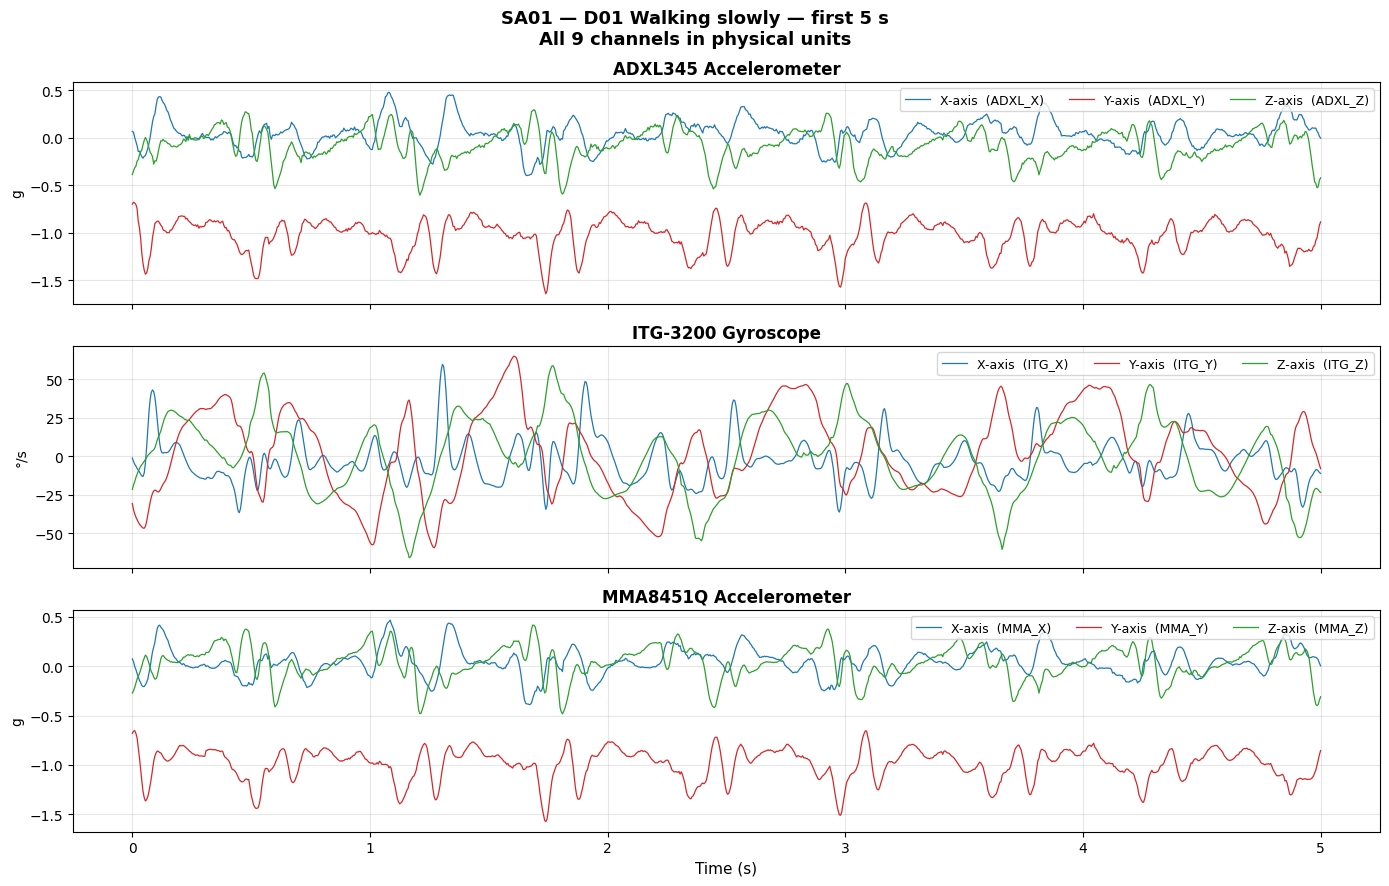

In [11]:
df_phys = df_adl_phys
t = np.arange(len(df_phys)) / 200.0   # seconds

# Show first 5 seconds (1000 samples)
mask = t <= 5.0

sensor_groups = [
    ('ADXL345 Accelerometer', ['ADXL_X', 'ADXL_Y', 'ADXL_Z'], 'g', 'tab:blue'),
    ('ITG-3200 Gyroscope',    ['ITG_X',  'ITG_Y',  'ITG_Z'],  '°/s', 'tab:orange'),
    ('MMA8451Q Accelerometer',['MMA_X',  'MMA_Y',  'MMA_Z'],  'g', 'tab:green'),
]

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axis_colors = ['#1f77b4', '#d62728', '#2ca02c']   # blue=X, red=Y, green=Z
axis_labels = ['X', 'Y', 'Z']

for ax, (title, cols, unit, _) in zip(axes, sensor_groups):
    for col, color, lbl in zip(cols, axis_colors, axis_labels):
        ax.plot(t[mask], df_phys[col][mask], color=color,
                linewidth=0.9, label=f'{lbl}-axis  ({col})')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(unit, fontsize=10)
    ax.legend(loc='upper right', fontsize=9, ncol=3)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (s)', fontsize=11)
fig.suptitle('SA01 — D01 Walking slowly — first 5 s\nAll 9 channels in physical units',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. ADL vs. Fall — ADXL345 comparison for SA01

The fall recording is 15 s long; the ADL is 100 s.  
We show the full fall and a 15-second slice from the ADL for a fair visual comparison.

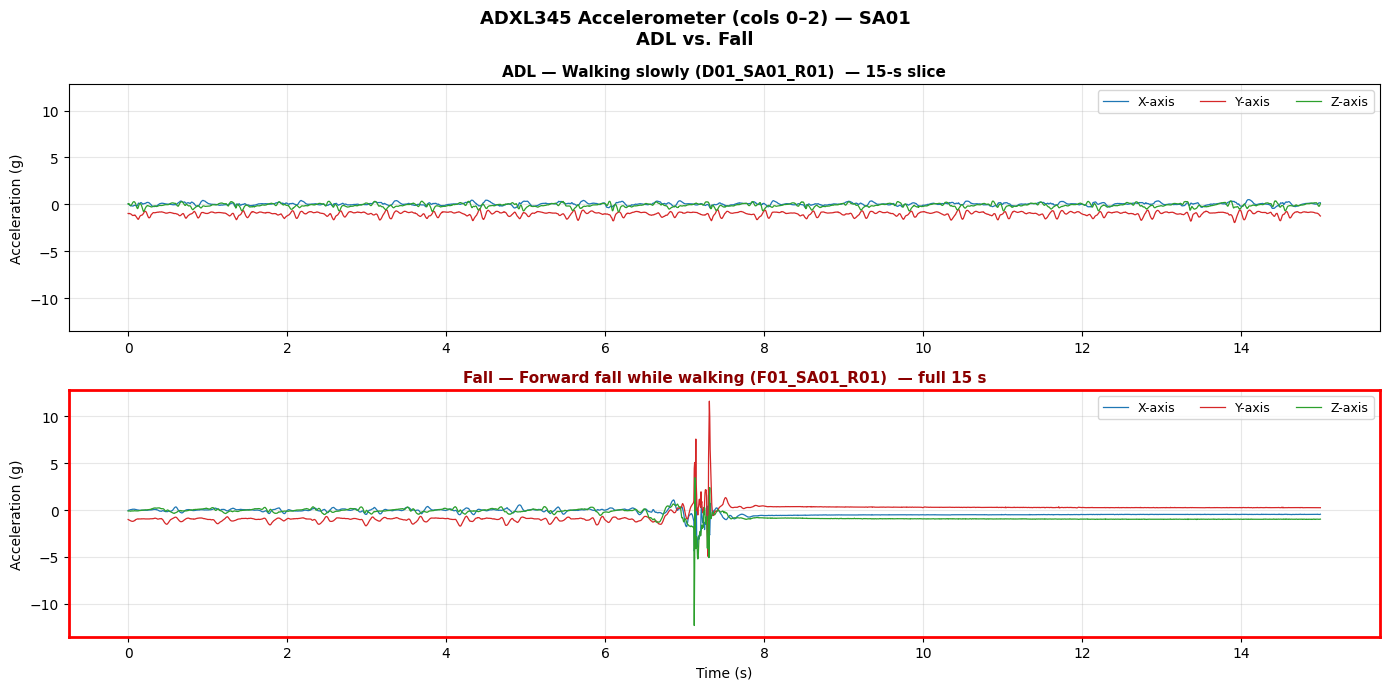

In [12]:
t_adl  = np.arange(len(df_adl_phys))  / 200.0
t_fall = np.arange(len(df_fall_phys)) / 200.0

# Use the middle 15 s of the ADL to capture steady-state walking
adl_start = int(40 * 200)   # 40 s into the recording
adl_end   = adl_start + int(15 * 200)
adl_slice = df_adl_phys.iloc[adl_start:adl_end]
t_adl_slice = np.arange(len(adl_slice)) / 200.0

axis_colors = ['#1f77b4', '#d62728', '#2ca02c']
axis_labels = ['X', 'Y', 'Z']
adxl_cols   = ['ADXL_X', 'ADXL_Y', 'ADXL_Z']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharey=True)

for col, color, lbl in zip(adxl_cols, axis_colors, axis_labels):
    ax1.plot(t_adl_slice, adl_slice[col].values, color=color,
             linewidth=0.9, label=f'{lbl}-axis')
ax1.set_title('ADL — Walking slowly (D01_SA01_R01)  — 15-s slice', fontsize=11, fontweight='bold')
ax1.set_ylabel('Acceleration (g)')
ax1.legend(ncol=3, fontsize=9, loc='upper right')
ax1.grid(True, alpha=0.3)

for col, color, lbl in zip(adxl_cols, axis_colors, axis_labels):
    ax2.plot(t_fall, df_fall_phys[col].values, color=color,
             linewidth=0.9, label=f'{lbl}-axis')
ax2.set_title('Fall — Forward fall while walking (F01_SA01_R01)  — full 15 s', fontsize=11,
              fontweight='bold', color='darkred')
ax2.set_ylabel('Acceleration (g)')
ax2.set_xlabel('Time (s)')
ax2.legend(ncol=3, fontsize=9, loc='upper right')
ax2.grid(True, alpha=0.3)
for spine in ax2.spines.values():
    spine.set_edgecolor('red')
    spine.set_linewidth(2)

fig.suptitle('ADXL345 Accelerometer (cols 0–2) — SA01\nADL vs. Fall',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. Cross-participant comparison — ADXL345 mean per axis during walking (D01)

Each subject wears the device at the waist.  
The dominant gravity component shifts across subjects based on how the sensor is oriented on their body.

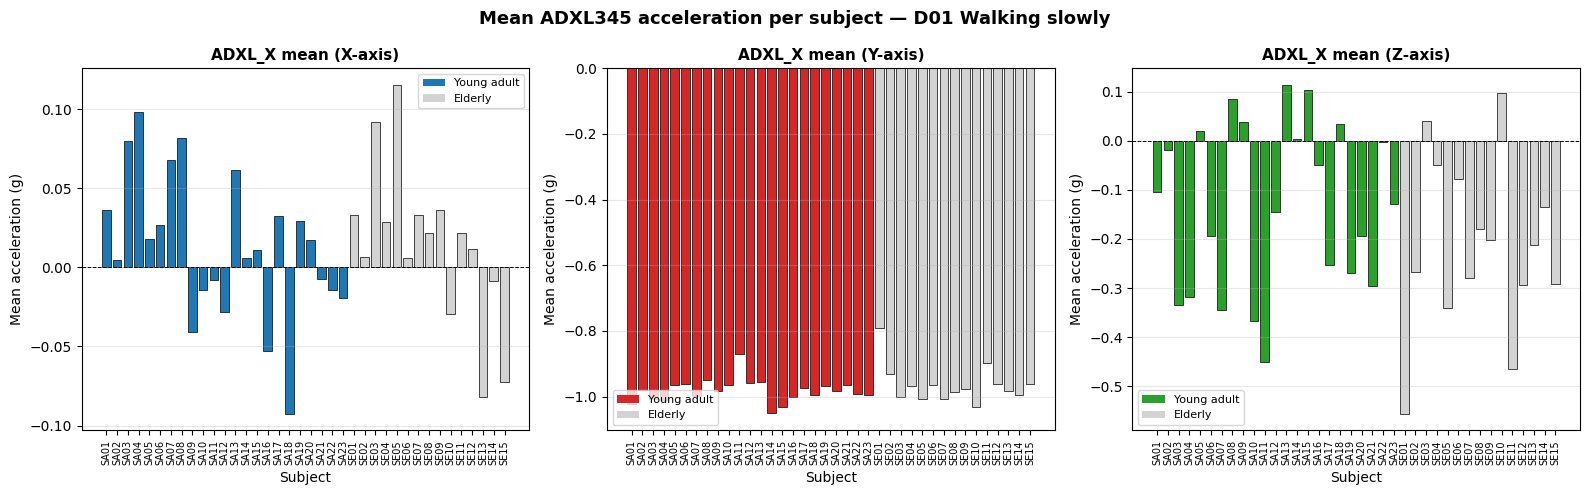

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, col, color in zip(axes,
                           ['ADXL_X_mean', 'ADXL_Y_mean', 'ADXL_Z_mean'],
                           axis_colors):
    axis_name = col.split('_')[1]   # X, Y, or Z
    bar_colors = [color if g == 'Young adult' else 'lightgrey'
                  for g in stats_df['group']]
    ax.bar(stats_df['subject'], stats_df[col], color=bar_colors, edgecolor='black',
           linewidth=0.5)
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax.set_title(f'ADXL_X mean ({axis_name}-axis)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Mean acceleration (g)')
    ax.set_xlabel('Subject')
    ax.tick_params(axis='x', rotation=90, labelsize=7)
    ax.grid(True, axis='y', alpha=0.3)
    # legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=color, label='Young adult'),
                       Patch(facecolor='lightgrey', label='Elderly')]
    ax.legend(handles=legend_elements, fontsize=8)

fig.suptitle('Mean ADXL345 acceleration per subject — D01 Walking slowly',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 11. Summary — column map cheat sheet

```
Raw file column index  →  Named column  →  Sensor  →  Signal  →  Unit
─────────────────────────────────────────────────────────────────────────
0   ADXL_X   ADXL345     Acceleration X    g    ← used by AFD-CNN
1   ADXL_Y   ADXL345     Acceleration Y    g    ← used by AFD-CNN
2   ADXL_Z   ADXL345     Acceleration Z    g    ← used by AFD-CNN
3   ITG_X    ITG-3200    Angular vel.  X   °/s
4   ITG_Y    ITG-3200    Angular vel.  Y   °/s
5   ITG_Z    ITG-3200    Angular vel.  Z   °/s
6   MMA_X    MMA8451Q    Acceleration X    g
7   MMA_Y    MMA8451Q    Acceleration Y    g
8   MMA_Z    MMA8451Q    Acceleration Z    g
─────────────────────────────────────────────────────────────────────────
Sample rate: 200 Hz   |   Device worn at waist
```

### What the AFD-CNN does with these columns

1. Reads columns **0–2** (ADXL345) only.
2. Downsamples 200 Hz → 100 Hz (every other row).
3. Slides a **2-second window** (200 samples × 3 axes = 600 values).
4. Normalises the 13-bit ADC range [−4096, +4095] → [0, 255].
5. Reshapes the 600 values into a **20×10×3** array (or repeats it to 20×20×3 in the *repeat-acc* variant).